In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Netflix Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (7789, 11)

First few rows:


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [2]:
# Basic information about the dataset
print("=== DATASET INFORMATION ===")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

=== DATASET INFORMATION ===
Shape: (7789, 11)
Columns: ['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description']

Data Types:
Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

Missing Values:
Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64


In [3]:
# Data Preprocessing and Cleaning

# 1. Handle missing values
print("Before handling missing values:")
print(df.isnull().sum())

# Fill missing values appropriately
df['Director'] = df['Director'].fillna('Unknown')
df['Cast'] = df['Cast'].fillna('Not Specified')
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna('Not Rated')

print("\nAfter handling missing values:")
print(df.isnull().sum())

Before handling missing values:
Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

After handling missing values:
Show_Id          0
Category         0
Title            0
Director         0
Cast             0
Country          0
Release_Date    10
Rating           0
Duration         0
Type             0
Description      0
dtype: int64


In [4]:
# 2. Feature Engineering - Extract year from Release_Date
def extract_year(date_str):
    try:
        if pd.isna(date_str):
            return np.nan
        # Extract year using regex
        year_match = re.search(r'\d{4}', str(date_str))
        if year_match:
            return int(year_match.group())
        return np.nan
    except:
        return np.nan

df['Release_Year'] = df['Release_Date'].apply(extract_year)

# 3. Extract duration numerical values and units
def extract_duration_info(duration):
    try:
        if pd.isna(duration):
            return np.nan, 'Unknown'

        duration_str = str(duration)

        # Extract number
        num_match = re.search(r'(\d+)', duration_str)
        if not num_match:
            return np.nan, 'Unknown'

        number = int(num_match.group(1))

        # Extract unit
        if 'Season' in duration_str:
            unit = 'Seasons'
        elif 'min' in duration_str.lower():
            unit = 'Minutes'
        else:
            unit = 'Unknown'

        return number, unit
    except:
        return np.nan, 'Unknown'

duration_info = df['Duration'].apply(extract_duration_info)
df['Duration_Value'] = duration_info.apply(lambda x: x[0])
df['Duration_Unit'] = duration_info.apply(lambda x: x[1])

# 4. Create content age feature
current_year = 2024
df['Content_Age'] = current_year - df['Release_Year']
df['Content_Age'] = df['Content_Age'].apply(lambda x: x if x >= 0 else np.nan)

print("New features created:")
print(df[['Release_Year', 'Duration_Value', 'Duration_Unit', 'Content_Age']].head())

New features created:
   Release_Year  Duration_Value Duration_Unit  Content_Age
0        2020.0               4       Seasons          4.0
1        2016.0              93       Minutes          8.0
2        2018.0              78       Minutes          6.0
3        2017.0              80       Minutes          7.0
4        2020.0             123       Minutes          4.0


In [5]:
# 5. Extract genres from Type and Description
def extract_genres(type_str, description):
    genres = []

    # Split Type column
    if pd.notna(type_str):
        type_genres = str(type_str).split(', ')
        genres.extend([genre.strip() for genre in type_genres])

    # Extract additional genres from description
    if pd.notna(description):
        desc_str = str(description).lower()
        common_genres = ['comedy', 'drama', 'action', 'romance', 'thriller', 'horror',
                        'documentary', 'sci-fi', 'fantasy', 'adventure', 'mystery',
                        'crime', 'animation', 'family', 'music', 'sport']

        for genre in common_genres:
            if genre in desc_str:
                genres.append(genre.title())

    return list(set(genres))  # Remove duplicates

df['Genres'] = df.apply(lambda row: extract_genres(row['Type'], row['Description']), axis=1)
df['Genre_Count'] = df['Genres'].apply(len)

In [6]:
print("Genre extraction completed")
df[['Type', 'Genres', 'Genre_Count']].head()

Genre extraction completed


,Type,Genres,Genre_Count
0,"International TV Shows, TV Dramas, TV Sci-Fi &...","[International TV Shows, TV Dramas, TV Sci-Fi ...",3
1,"Dramas, International Movies","[International Movies, Dramas]",2
2,"Horror Movies, International Movies","[Horror Movies, International Movies]",2
3,"Action & Adventure, Independent Movies, Sci-Fi...","[Independent Movies, Sci-Fi & Fantasy, Action ...",3
4,Dramas,[Dramas],1


In [7]:
# Data Analysis

print("=== BASIC STATISTICS ===")
print(f"Total shows/movies: {len(df)}")
print(f"Movies: {len(df[df['Category'] == 'Movie'])}")
print(f"TV Shows: {len(df[df['Category'] == 'TV Show'])}")

# Content distribution by category
category_dist = df['Category'].value_counts()
print("\nContent by Category:")
category_dist

=== BASIC STATISTICS ===
Total shows/movies: 7789
Movies: 5379
TV Shows: 2410

Content by Category:


,count
Category,
Movie,5379
TV Show,2410


In [8]:
# GroupBy Operations

# 1. Group by Category and get statistics
category_stats = df.groupby('Category').agg({
    'Show_Id': 'count',
    'Release_Year': ['min', 'max', 'mean'],
    'Duration_Value': 'mean',
    'Genre_Count': 'mean'
}).round(2)

print("Category-wise Statistics:")
print(category_stats)

Category-wise Statistics:
         Show_Id Release_Year                  Duration_Value Genre_Count
           count          min     max     mean           mean        mean
Category                                                                 
Movie       5379       2008.0  2021.0  2018.48          99.31        2.42
TV Show     2410       2008.0  2021.0  2018.52           1.78        2.62


In [9]:
# 2. Group by Rating
rating_analysis = df.groupby('Rating').agg({
    'Show_Id': 'count',
    'Release_Year': 'mean',
    'Duration_Value': 'mean'
}).round(2).sort_values(by=('Show_Id'), ascending=False)

print("Content by Rating:")
print(rating_analysis)

Content by Rating:
           Show_Id  Release_Year  Duration_Value
Rating                                          
TV-MA         2865       2018.46           62.10
TV-14         1931       2018.45           73.56
TV-PG          806       2018.19           60.00
R              665       2018.89          106.15
PG-13          386       2019.10          107.77
TV-Y           280       2018.77           20.50
TV-Y7          271       2018.17           22.97
PG             247       2018.95           98.53
TV-G           194       2018.62           46.55
NR              84       2016.55           89.99
G               39       2018.41           88.08
Not Rated        7       2016.71           54.00
TV-Y7-FV         6       2016.67           57.33
UR               5       2018.60          106.80
NC-17            3       2017.33          125.00


In [10]:
# 3. Group by Country (top 10)
country_counts = df['Country'].value_counts().head(10)
print("Top 10 Countries by Content:")
country_counts

Top 10 Countries by Content:


,count
Country,
United States,2556
India,923
Unknown,507
United Kingdom,397
Japan,226
South Korea,183
Canada,177
Spain,134
France,115


In [11]:
# 4. Group by Release Year (last 20 years)
recent_years = df[df['Release_Year'] >= 2000]
yearly_content = recent_years.groupby('Release_Year').agg({
    'Show_Id': 'count',
    'Category': lambda x: (x == 'Movie').sum()
}).rename(columns={'Show_Id': 'Total_Content', 'Category': 'Movies'})
yearly_content['TV_Shows'] = yearly_content['Total_Content'] - yearly_content['Movies']

print("Yearly Content Distribution (2000-2024):")
yearly_content.tail(10)

Yearly Content Distribution (2000-2024):


,Total_Content,Movies,TV_Shows
Release_Year,,,
2012.0,3,3,0
2013.0,11,6,5
2014.0,25,19,6
2015.0,88,58,30
2016.0,443,258,185
2017.0,1225,864,361
2018.0,1685,1255,430
2019.0,2154,1498,656
2020.0,2010,1313,697


In [12]:
# Melt Function Example - Reshaping data

# Create a sample dataframe for melting
melt_df = df[['Category', 'Rating', 'Release_Year', 'Duration_Value']].head(100).copy()

# Melt the dataframe
melted_df = pd.melt(melt_df,
                    id_vars=['Category', 'Rating'],
                    value_vars=['Release_Year', 'Duration_Value'],
                    var_name='Metric',
                    value_name='Value')

print("Original DataFrame shape:", melt_df.shape)
print("Melted DataFrame shape:", melted_df.shape)
print("\nMelted DataFrame sample:")
melted_df.head(10)


Original DataFrame shape: (100, 4)
Melted DataFrame shape: (200, 4)

Melted DataFrame sample:


,Category,Rating,Metric,Value
0,TV Show,TV-MA,Release_Year,2020.0
1,Movie,TV-MA,Release_Year,2016.0
2,Movie,R,Release_Year,2018.0
3,Movie,PG-13,Release_Year,2017.0
4,Movie,PG-13,Release_Year,2020.0
5,TV Show,TV-MA,Release_Year,2017.0
6,Movie,TV-MA,Release_Year,2020.0
7,Movie,R,Release_Year,2019.0
8,Movie,TV-14,Release_Year,2019.0
9,Movie,TV-MA,Release_Year,2017.0


In [13]:
# Filtering Operations

# 1. Filter recent content (last 5 years)
recent_content = df[df['Release_Year'] >= 2019]
print(f"Recent content (2019-2024): {len(recent_content)}")

# 2. Filter by duration
long_movies = df[(df['Category'] == 'Movie') & (df['Duration_Value'] > 120)]
print(f"Long movies (>2 hours): {len(long_movies)}")

# 3. Filter by multiple conditions
popular_genres = ['Dramas', 'Comedies', 'Action & Adventure']
popular_content = df[df['Type'].str.contains('|'.join(popular_genres), na=False)]
print(f"Content in popular genres: {len(popular_content)}")

# 4. Filter TV shows with multiple seasons
multi_season_shows = df[(df['Category'] == 'TV Show') & (df['Duration_Value'] > 1)]
print(f"TV shows with multiple seasons: {len(multi_season_shows)}")

Recent content (2019-2024): 4281
Long movies (>2 hours): 1011
Content in popular genres: 4739
TV shows with multiple seasons: 802


In [14]:
# Advanced Feature Creation

# 1. Create content length categories
def categorize_duration(duration_value, category, unit):
    if pd.isna(duration_value):
        return 'Unknown'

    if category == 'Movie':
        if duration_value < 60:
            return 'Short Film'
        elif duration_value <= 120:
            return 'Standard Movie'
        else:
            return 'Long Movie'
    else:  # TV Show
        if duration_value == 1:
            return 'Single Season'
        elif duration_value <= 3:
            return 'Short Series'
        else:
            return 'Long Series'

df['Duration_Category'] = df.apply(
    lambda row: categorize_duration(row['Duration_Value'], row['Category'], row['Duration_Unit']),
    axis=1
)

# 2. Create popularity score (simulated based on release year and duration)
df['Popularity_Score'] = (
    (df['Release_Year'] - 1990) / 10 +  # Newer content gets higher score
    (df['Duration_Value'] / df['Duration_Value'].max()) +  # Longer content gets higher score
    (df['Genre_Count'] / df['Genre_Count'].max())  # More genres gets higher score
).round(2)

print("Advanced features created:")
print(df[['Duration_Category', 'Popularity_Score']].head())

Advanced features created:
  Duration_Category  Popularity_Score
0       Long Series              3.51
1    Standard Movie              3.23
2    Standard Movie              3.38
3    Standard Movie              3.46
4        Long Movie              3.56


In [15]:
# Moving Average Calculation

# Calculate moving average of content releases per year
yearly_counts = df.groupby('Release_Year').size()

# Remove NaN years
yearly_counts = yearly_counts.dropna()

# Calculate 3-year moving average
moving_avg_3 = yearly_counts.rolling(window=3, min_periods=1).mean()

# Calculate 5-year moving average
moving_avg_5 = yearly_counts.rolling(window=5, min_periods=1).mean()

print("Moving averages calculated")
print(f"3-year MA recent values: {moving_avg_3.tail(5)}")
print(f"5-year MA recent values: {moving_avg_5.tail(5)}")

Moving averages calculated
3-year MA recent values: Release_Year
2017.0     585.333333
2018.0    1117.666667
2019.0    1688.000000
2020.0    1949.666667
2021.0    1427.000000
dtype: float64
5-year MA recent values: Release_Year
2017.0     358.4
2018.0     693.2
2019.0    1119.0
2020.0    1503.4
2021.0    1438.2
dtype: float64


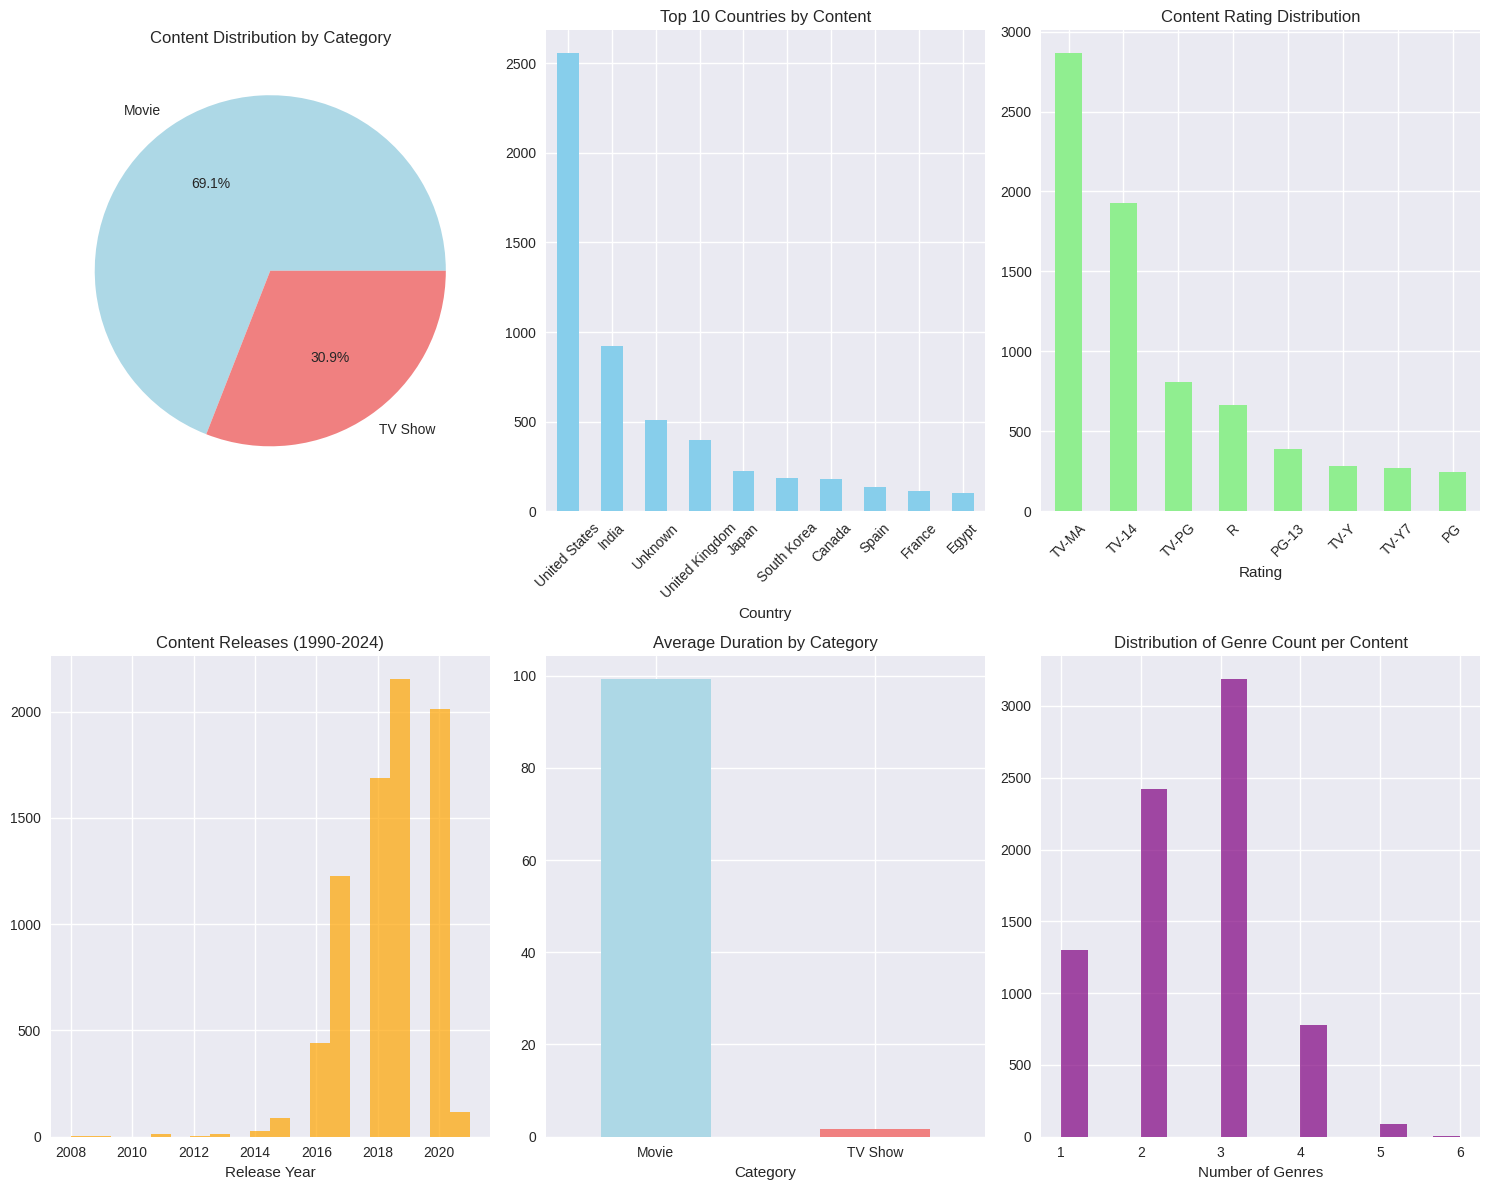

In [16]:
# Data Visualization

# 1. Content distribution by Category
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Content Distribution by Category')
plt.ylabel('')

# 2. Top 10 Countries
plt.subplot(2, 3, 2)
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Content')
plt.xticks(rotation=45)

# 3. Rating distribution
plt.subplot(2, 3, 3)
df['Rating'].value_counts().head(8).plot(kind='bar', color='lightgreen')
plt.title('Content Rating Distribution')
plt.xticks(rotation=45)

# 4. Release Year distribution (last 30 years)
plt.subplot(2, 3, 4)
recent_years = df[df['Release_Year'] >= 1990]['Release_Year']
recent_years.hist(bins=20, color='orange', alpha=0.7)
plt.title('Content Releases (1990-2024)')
plt.xlabel('Release Year')

# 5. Duration distribution by category
plt.subplot(2, 3, 5)
category_durations = df.groupby('Category')['Duration_Value'].mean()
category_durations.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Average Duration by Category')
plt.xticks(rotation=0)

# 6. Genre count distribution
plt.subplot(2, 3, 6)
df['Genre_Count'].hist(bins=15, color='purple', alpha=0.7)
plt.title('Distribution of Genre Count per Content')
plt.xlabel('Number of Genres')

plt.tight_layout()
plt.show()

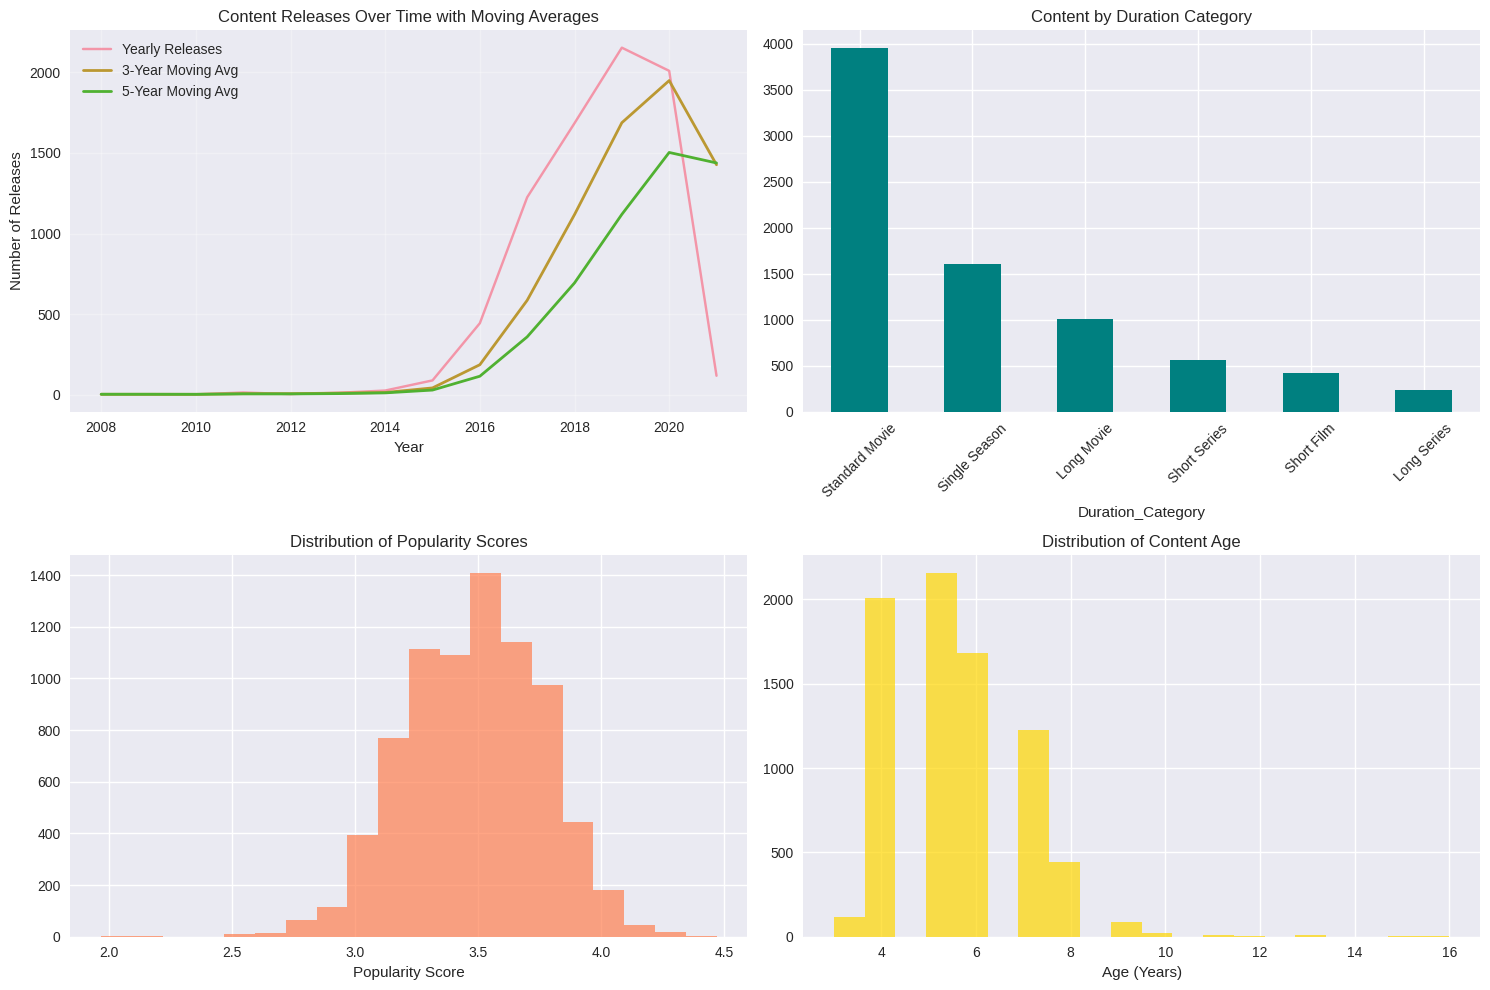

In [17]:
# More Advanced Visualizations

plt.figure(figsize=(15, 10))

# 1. Moving average of content releases
plt.subplot(2, 2, 1)
plt.plot(yearly_counts.index, yearly_counts.values, label='Yearly Releases', alpha=0.7)
plt.plot(moving_avg_3.index, moving_avg_3.values, label='3-Year Moving Avg', linewidth=2)
plt.plot(moving_avg_5.index, moving_avg_5.values, label='5-Year Moving Avg', linewidth=2)
plt.title('Content Releases Over Time with Moving Averages')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Duration categories
plt.subplot(2, 2, 2)
duration_cat_counts = df['Duration_Category'].value_counts()
duration_cat_counts.plot(kind='bar', color='teal')
plt.title('Content by Duration Category')
plt.xticks(rotation=45)

# 3. Popularity score distribution
plt.subplot(2, 2, 3)
df['Popularity_Score'].hist(bins=20, color='coral', alpha=0.7)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity Score')

# 4. Content age distribution
plt.subplot(2, 2, 4)
df['Content_Age'].hist(bins=20, color='gold', alpha=0.7)
plt.title('Distribution of Content Age')
plt.xlabel('Age (Years)')

plt.tight_layout()
plt.show()

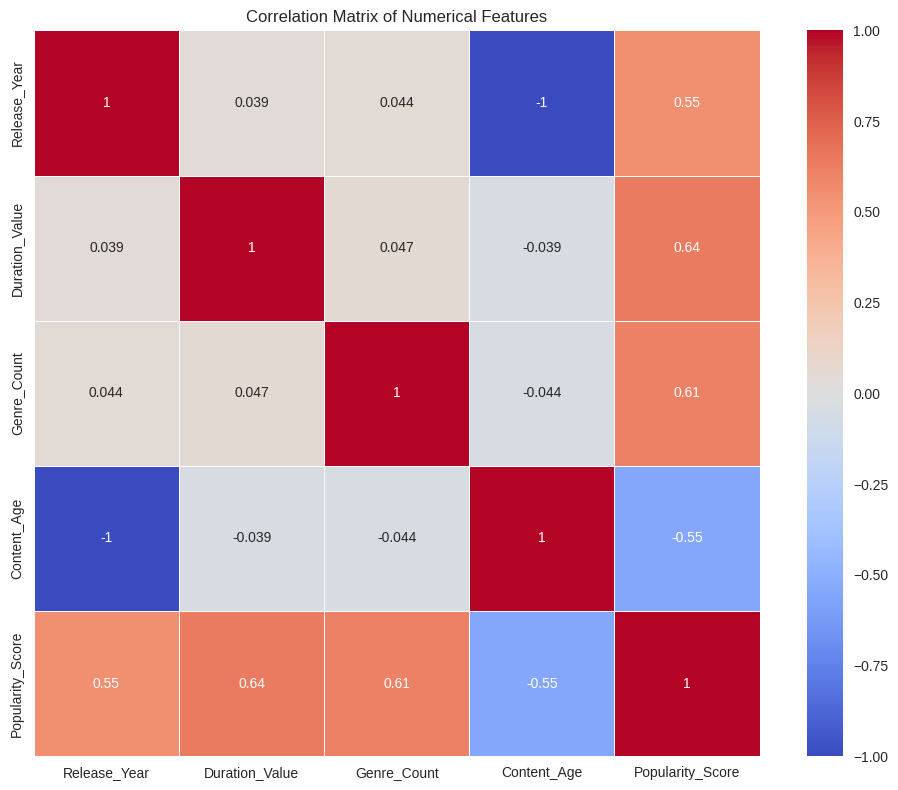

Correlation Matrix:
                  Release_Year  Duration_Value  Genre_Count  Content_Age  \
Release_Year          1.000000        0.039003     0.043666    -1.000000   
Duration_Value        0.039003        1.000000     0.046966    -0.039003   
Genre_Count           0.043666        0.046966     1.000000    -0.043666   
Content_Age          -1.000000       -0.039003    -0.043666     1.000000   
Popularity_Score      0.551929        0.638773     0.610691    -0.551929   

                  Popularity_Score  
Release_Year              0.551929  
Duration_Value            0.638773  
Genre_Count               0.610691  
Content_Age              -0.551929  
Popularity_Score          1.000000  


In [18]:
# Correlation Analysis

# Select numerical columns for correlation
numerical_cols = ['Release_Year', 'Duration_Value', 'Genre_Count', 'Content_Age', 'Popularity_Score']
correlation_df = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_df)

In [20]:
# Advanced GroupBy with Multiple Aggregations

# Group by Category and Rating
category_rating_analysis = df.groupby(['Category', 'Rating']).agg({
    'Show_Id': 'count',
    'Release_Year': ['mean', 'min', 'max'],
    'Duration_Value': ['mean', 'std'],
    'Popularity_Score': 'mean'
}).round(2)

print("Detailed Analysis by Category and Rating:")
category_rating_analysis.head(10)

Detailed Analysis by Category and Rating:


Show_Id Release_Year                 Duration_Value         \
                     count         mean     min     max           mean    std   
Category Rating                                                                 
Movie    G              39      2018.41  2014.0  2021.0          88.08  25.70   
         NC-17           3      2017.33  2016.0  2019.0         125.00  49.79   
         NR             79      2016.58  2010.0  2019.0          95.44  18.18   
         Not Rated       5      2016.60  2016.0  2017.0          75.20  28.31   
         PG            247      2018.95  2012.0  2021.0          98.53  17.60   
         PG-13         386      2019.10  2015.0  2021.0         107.77  19.53   
         R             663      2018.89  2012.0  2021.0         106.47  18.34   
         TV-14        1272      2018.50  2011.0  2021.0         110.71  30.73   
         TV-G          111      2018.63  2013.0  2021.0          79.93  29.47   
         TV-MA        1847      2018.29  2008.0  2021.0          95.39  24.21   

                   Popularity_Score  
                               mean  
Category Rating                      
Movie    G                     3.47  
         NC-17                 3.52  
         NR                    3.36  
         Not Rated             3.13  
         PG                    3.60  
         PG-13                 3.64  
         R                     3.60  
         TV-14                 3.65  
         TV-G                  3.52  
         TV-MA                 3.54

In [21]:
# Text Analysis - Most common words in descriptions

from collections import Counter
import string

# Extract words from descriptions
def clean_text(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    # Remove common stop words
    stop_words = {'the', 'and', 'a', 'an', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

all_words = []
for desc in df['Description'].dropna():
    all_words.extend(clean_text(desc))

word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

print("Most common words in descriptions:")
for word, count in common_words:
    print(f"{word}: {count}")

Most common words in descriptions:
his: 3014
her: 1883
their: 1470
when: 1326
this: 1246
from: 1115
after: 865
who: 751
that: 742
life: 696
but: 683
young: 655
into: 616
new: 603
family: 494
they: 457
man: 448
love: 441
two: 435
world: 429


In [22]:
# Final Summary Statistics

print("=== PROJECT SUMMARY ===")
print(f"Total records processed: {len(df)}")
print(f"Movies: {len(df[df['Category'] == 'Movie'])}")
print(f"TV Shows: {len(df[df['Category'] == 'TV Show'])}")
print(f"Time range: {df['Release_Year'].min()} - {df['Release_Year'].max()}")
print(f"Countries represented: {df['Country'].nunique()}")
print(f"Unique ratings: {df['Rating'].nunique()}")

# Memory usage
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data quality metrics
completeness = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Data completeness: {completeness:.2f}%")

# Most common duration category
most_common_duration = df['Duration_Category'].mode()[0]
print(f"Most common duration category: {most_common_duration}")

# Average popularity score
avg_popularity = df['Popularity_Score'].mean()
print(f"Average popularity score: {avg_popularity:.2f}")

=== PROJECT SUMMARY ===
Total records processed: 7789
Movies: 5379
TV Shows: 2410
Time range: 2008.0 - 2021.0
Countries represented: 682
Unique ratings: 15

Memory usage: 9.07 MB
Data completeness: 99.97%
Most common duration category: Standard Movie
Average popularity score: 3.48
